In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

yu.setpath('check_c2pt_strategies')

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['b','c','d','e']

In [2]:
ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2Njk[ens]=len(c2pt)
    print(ens,len(c2pt))

b 725
c 400
d 493
e 460


In [3]:
ens2tminss={
        'b':[range(8,25+1),range(1,10+1),range(1,5+1)],
        'c':[range(8,29+1),range(1,16+1),range(1,6+1)],
        'd':[range(8,33+1),range(1,18+1),range(1,7+1)],
        'e':[range(8,39+1),range(1,18+1),range(1,7+1)],
    }
ens2tminss_ds2={
        'b':[range(8,25+1),range(1,10+1),range(1,4+1)],
        'c':[range(8,29+1),range(1,16+1),range(1,5+1)],
        'd':[range(8,33+1),range(1,18+1),range(1,6+1)],
        'e':[range(8,39+1),range(1,18+1),range(1,6+1)],
    }
ens2tminss_large={
        'b':[range(8,25+1),range(1,9+1),range(1,1+1)],
        'c':[range(8,29+1),range(1,10+1),range(1,1+1)],
        'd':[range(8,33+1),range(1,11+1),range(1,1+1)],
        'e':[range(8,39+1),range(1,13+1),range(1,1+1)],
    } # used for large momenta

mN_ref=(yu.m_proton+yu.m_neutron)/2

path='data_aux/DmN_ChPT.csv'
df=pd.read_csv(path, index_col=0)
def func(ele):
    m,e=ele.split(',')
    m=m.split('(')[-1]
    e=e.split(')')[0]
    return float(m),float(e)

dic_DmN_ChPT={(row_label, col_label): func(df.loc[row_label, col_label])
    for row_label in df.index
    for col_label in df.columns
}

ens2DmN_N2LO={ens:dic_DmN_ChPT[(yu.ens2label[ens],'DmN_N2LO')] for ens in enss}
ens2DmN_N2LO={ens:yu.jackknife_pseudo(ens2DmN_N2LO[ens][0],ens2DmN_N2LO[ens][1],ens2Njk[ens])[:,0] for ens in enss}
print({ens:yu.jackme_un2str(ens2DmN_N2LO[ens]) for ens in enss})

{'b': '-4.50(38)', 'c': '-1.32(47)', 'd': '-5.33(45)', 'e': '-1.24(44)'}


In [4]:
for ds in [1,2,3]:
    for corrQ in [True,False]:
        for ens in enss:
            # print(ds,corrQ,ens)
            meff=yu.jackmap(yu.c2pt2meff,ens2c2pt0[ens])
            tminss=ens2tminss[ens]
            if ds in [2,3]:
                tminss=ens2tminss_ds2[ens]
            fitss_2pt=yu.doFits_meff_nst(meff,tminss,[0.4,0.5,2,0.8,1],downSampling=ds,corrQ=corrQ,label=f'meff_{ens}_{ds}_{corrQ}',debugQ=True)

16 28 19.495042145485495 11 1.7722765586804996
16.456171024508656 [0.0,1.2,0.0,0.1,0.0,4.7,0.9,0.3,5.4,2.1,1.2,0.6]


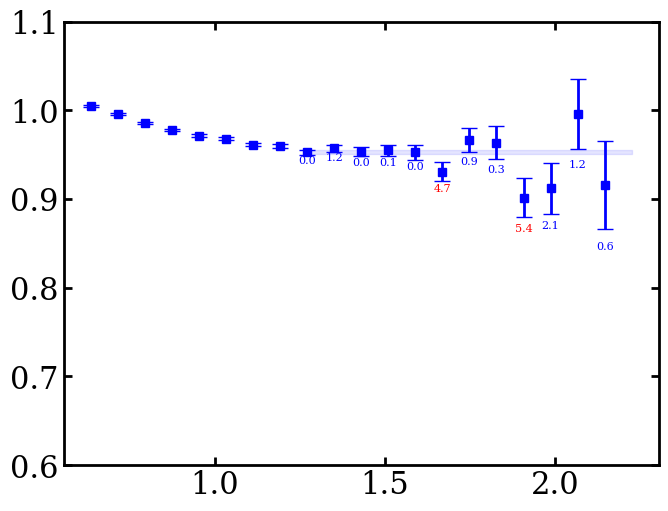

In [11]:
for ens in ['b']:
    xunit=yu.ens2a[ens]; yunit=yu.ens2aInv[ens]/1000
    meff=yu.jackmap(yu.c2pt2meff,ens2c2pt0[ens])
    
    fig,axs=yu.getFigAxs(1,1)
    ax=axs[0,0]
    ax.set_ylim([0.6,1.1])
    
    mean,err=yu.jackme(meff)
    
    fitmax=yu.find_fitmax(meff)
    
    ts=np.arange(8,fitmax)
    plt_x=ts*xunit; plt_y=mean[ts]*yunit; plt_yerr=err[ts]*yunit
    ax.errorbar(plt_x,plt_y,plt_yerr,color='b')
    
    fitmin={'b':16,'c':19}[ens]
    
    ts_fit = np.arange(fitmin, fitmax)
    meff_fit=meff[:,ts_fit]
    
    ds=1; corrQ=True
    fit=yu.doFit_const(meff_fit,corrQ=True)
    pars_jk,chi2_jk,Ndof=fit
    pars=np.mean(pars_jk)
    print(fitmin,fitmax,np.mean(chi2_jk),Ndof,np.mean(chi2_jk)/Ndof)
    mean,err,cov=yu.jackmec(meff_fit)
    chi2perp=np.abs((pars-mean)/err)**2
    print(np.sum(chi2perp),yu.formatList(chi2perp,fmt='.1f'))
    

    mean,err=yu.jackme(pars_jk[:,0])
    xs=np.array([fitmin,fitmax])*xunit; ymin=(mean-err)*yunit; ymax=(mean+err)*yunit
    ax.fill_between(xs, ymin, ymax, color='b', alpha=0.1)
    
    # mark per-point chi2 contribution under each fitted point
    mean,err,cov=yu.jackmec(meff_fit)
    plt_x_fit = ts_fit * xunit
    plt_y_fit = mean * yunit          # here mean,err are from yu.jackmec(meff_fit)
    plt_yerr_fit = err * yunit

    bad_thr = 4.0   # threshold for bad points

    for x, y, yerr_i, chi in zip(plt_x_fit, plt_y_fit, plt_yerr_fit, chi2perp):
        is_bad = chi > bad_thr
        txt_color = 'r' if is_bad else 'b'

        # put the chi2 contribution slightly below the error bar
        ax.text(
            x, y - 1.3 * yerr_i,
            f'{chi:.1f}',
            ha='center', va='top',
            fontsize=8,
            color=txt_color
        )

        # # circle bad points
        # if is_bad:
        #     ax.scatter(
        #         [x], [y],
        #         s=350,                 # circle size
        #         facecolors='none',
        #         edgecolors='r',
        #         linewidths=1.5,
        #         zorder=5
        #     )

In [8]:
ens='b'; ds=1; corrQ=True
fits=yu.getFits(f'meff_{ens}_{ds}_{corrQ}')[0]
yu.printFits(fits)

Model average: pars=['0.3793(23)'], most probable fitlabel: 16, prob=30%, chi2/Ndof=25.2/14=1.8;
fitlabel=8, pars=['0.39826(21)'], prob=0%, chi2/Ndof=1216.2/22=55.2;
fitlabel=9, pars=['0.39537(24)'], prob=0%, chi2/Ndof=636.1/21=30.2;
fitlabel=10, pars=['0.39285(28)'], prob=0%, chi2/Ndof=300.3/20=15.0;
fitlabel=11, pars=['0.39084(32)'], prob=0%, chi2/Ndof=153.6/19=8.0;
fitlabel=12, pars=['0.38927(38)'], prob=0%, chi2/Ndof=86.5/18=4.8;
fitlabel=13, pars=['0.38770(48)'], prob=0%, chi2/Ndof=57.0/17=3.3;
fitlabel=14, pars=['0.38584(61)'], prob=4%, chi2/Ndof=33.2/16=2.0;
fitlabel=15, pars=['0.38502(74)'], prob=9%, chi2/Ndof=29.5/15=1.9;
fitlabel=16, pars=['0.38381(95)'], prob=30%, chi2/Ndof=25.2/14=1.8;
fitlabel=17, pars=['0.3839(12)'], prob=11%, chi2/Ndof=25.2/13=1.9;
fitlabel=18, pars=['0.3830(16)'], prob=6%, chi2/Ndof=24.3/12=2.0;
fitlabel=19, pars=['0.3824(19)'], prob=2%, chi2/Ndof=24.1/11=2.1;
fitlabel=20, pars=['0.3801(25)'], prob=2%, chi2/Ndof=22.0/10=2.2;
fitlabel=21, pars=['0.3779(3

In [6]:
def run(ds,corrQ):
    ens='b'
    fitss=yu.getFits(f'meff_{ens}_{ds}_{corrQ}')
    nst2tminphy={}
    for nst,fits in zip([1,2,3],fitss):
        # if nst==1:
        #     fits=[fit for fit in fits if fit[0]*yu.ens2a[ens]>1.3]
        pars_jk,probs_jk=yu.jackMA(fits)
        probs=np.mean(probs_jk,axis=0)
        ind=np.argmax(probs)
        tmin=fits[ind][0]
        nst2tminphy[nst]=tmin*yu.ens2a[ens]

    nst2ens2tmin={}
    for nst in nst2tminphy.keys():
        nst2ens2tmin[nst]={}
        for ens in enss:
            nst2ens2tmin[nst][ens]=round(nst2tminphy[nst]/yu.ens2a[ens])

        print(f'{nst}st fit:',f'{nst2tminphy[nst]:.02f} fm',nst2ens2tmin[nst])
        
        
    figs=[]; ens2pars_jk_meff1st={}; ens2pars_jk_meff2st={}; ens2pars_jk_meff3st={}
    for ens in enss:
        meff=yu.jackmap(yu.c2pt2meff,ens2c2pt0[ens])
        tminss=ens2tminss[ens]
        
        selections={f'{nst}st':nst2ens2tmin[nst][ens] for nst in [1,2,3]}
        
        fitss_2pt=yu.getFits(f'meff_{ens}_{ds}_{corrQ}')
        fig,axd,result=yu.makePlot_2pt_SimoneStyle(meff,fitss_2pt,xunit=yu.ens2a[ens],yunit=yu.ens2aInv[ens]/1000,E0_ref=mN_ref/1000,ylims='std_N',\
            selection=selections)
        fig.suptitle(yu.ens2full[ens])
        yu.finalizePlot(closeQ=True)
        figs.append(fig) 
        
        ens2pars_jk_meff1st[ens]=result['1st']
        ens2pars_jk_meff2st[ens]=result['2st']
        ens2pars_jk_meff3st[ens]=result['3st']
        

    ens2dats=[{ens:ens2pars_jk_meffnst[ens][:,0]*yu.ens2aInv[ens] for ens in enss} for ens2pars_jk_meffnst in [ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]]
    fitss=[yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yum.lat_a2s_plt) for ens2dat in ens2dats]
    matrix_dic=[{
        'ens2dat':ens2dats[ist],
        'fit:[fits,lat_a2s_plt]':[fitss[ist],yum.lat_a2s_plt]
        } for ist in range(len(ens2dats))]
    fig,axs=yu.makePlot_continuumExtrapolation(matrix_dic,shows=['MA'])
    yu.addColHeader(axs,['1st','2st','3st'])
    ax=axs[0,0]
    ax.set_ylim([920,960])
    ax.set_ylabel(r'$m_N$ [MeV]')
    for icol in range(len(matrix_dic)):
        ax=axs[0,icol]
        yu.addRefLine(ax,mN_ref,label=r'$m_N^{\mathrm{exp}}=$'+'%0.3f'%mN_ref)
        ax.legend(fontsize=16)  
    yu.finalizePlot(closeQ=True)
    figs.append(fig)

    ens2dats=[{ens:ens2pars_jk_meffnst[ens][:,0]*yu.ens2aInv[ens]+ens2DmN_N2LO[ens] for ens in enss} for ens2pars_jk_meffnst in [ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]]
    fitss=[yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yum.lat_a2s_plt) for ens2dat in ens2dats]
    matrix_dic=[{
        'ens2dat':ens2dats[ist],
        'fit:[fits,lat_a2s_plt]':[fitss[ist],yum.lat_a2s_plt]
        } for ist in range(len(ens2dats))]
    fig,axs=yu.makePlot_continuumExtrapolation(matrix_dic,shows=['MA'])
    yu.addColHeader(axs,['1st','2st','3st'])
    ax=axs[0,0]
    ax.set_ylim([920,960])
    ax.set_ylabel(r'$m_N$ [MeV]')
    for icol in range(len(matrix_dic)):
        ax=axs[0,icol]
        yu.addRefLine(ax,mN_ref,label=r'$m_N^{\mathrm{exp}}=$'+'%0.3f'%mN_ref)
        ax.legend(fontsize=16)  
    fig.suptitle(r'corrected using $O(p^3)$ ChPT')
    yu.finalizePlot(closeQ=True)
    figs.append(fig)

    yu.makePDF(f'meff_{ds}_{corrQ}',figs)
    
for ds in [1,2,3]:
    for corrQ in [True,False]:
        print(ds,corrQ)
        run(ds,corrQ)

1 True
1st fit: 1.27 fm {'b': 16, 'c': 19, 'd': 22, 'e': 26}
2st fit: 0.64 fm {'b': 8, 'c': 9, 'd': 11, 'e': 13}
3st fit: 0.32 fm {'b': 4, 'c': 5, 'd': 6, 'e': 6}


1 False
1st fit: 1.27 fm {'b': 16, 'c': 19, 'd': 22, 'e': 26}
2st fit: 0.64 fm {'b': 8, 'c': 9, 'd': 11, 'e': 13}
3st fit: 0.32 fm {'b': 4, 'c': 5, 'd': 6, 'e': 6}
2 True
1st fit: 1.27 fm {'b': 16, 'c': 19, 'd': 22, 'e': 26}
2st fit: 0.64 fm {'b': 8, 'c': 9, 'd': 11, 'e': 13}
3st fit: 0.16 fm {'b': 2, 'c': 2, 'd': 3, 'e': 3}
2 False
1st fit: 1.27 fm {'b': 16, 'c': 19, 'd': 22, 'e': 26}
2st fit: 0.64 fm {'b': 8, 'c': 9, 'd': 11, 'e': 13}
3st fit: 0.16 fm {'b': 2, 'c': 2, 'd': 3, 'e': 3}
3 True
1st fit: 1.27 fm {'b': 16, 'c': 19, 'd': 22, 'e': 26}
2st fit: 0.48 fm {'b': 6, 'c': 7, 'd': 8, 'e': 10}
3st fit: 0.24 fm {'b': 3, 'c': 3, 'd': 4, 'e': 5}
3 False
1st fit: 1.27 fm {'b': 16, 'c': 19, 'd': 22, 'e': 26}
2st fit: 0.56 fm {'b': 7, 'c': 8, 'd': 10, 'e': 11}
3st fit: 0.24 fm {'b': 3, 'c': 3, 'd': 4, 'e': 5}
